In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set a professional style for our business visualizations
plt.style.use('ggplot')

# Load the raw dataset
# Using relative path from the notebooks directory
raw_data_path = '../data/raw/sales_data.csv'
df = pd.read_csv(raw_data_path)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [36]:
# 1. Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# 2. Convert 'Date' to actual datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 3. Verify 'Total_Sales' calculation (Quantity * Price)
# This is a good sanity check for data integrity
df['Calculated_Sales'] = df['Quantity'] * df['Price']
sales_match = (df['Calculated_Sales'] == df['Total_Sales']).all()
print(f"\nDo all Total_Sales match Quantity * Price? {sales_match}")

# Drop the temporary calculation column
df = df.drop(columns=['Calculated_Sales'])

print("\nCleaned Data Types:")
print(df.dtypes)

Missing values per column:
 Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Do all Total_Sales match Quantity * Price? True

Cleaned Data Types:
Date           datetime64[us]
Product                   str
Quantity                int64
Price                   int64
Customer_ID               str
Region                    str
Total_Sales             int64
dtype: object


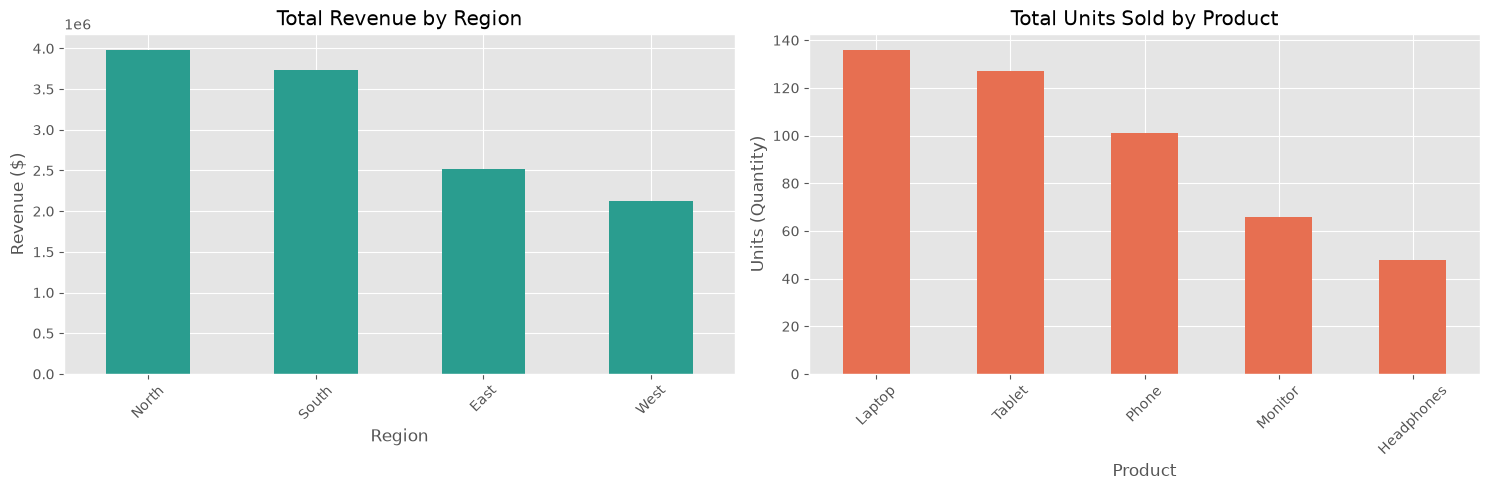

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Total Sales by Region
region_sales = df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Total Revenue by Region')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Most Demanded Products (by Quantity)
product_demand = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
product_demand.plot(kind='bar', ax=axes[1], color='#e76f51')
axes[1].set_title('Total Units Sold by Product')
axes[1].set_ylabel('Units (Quantity)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

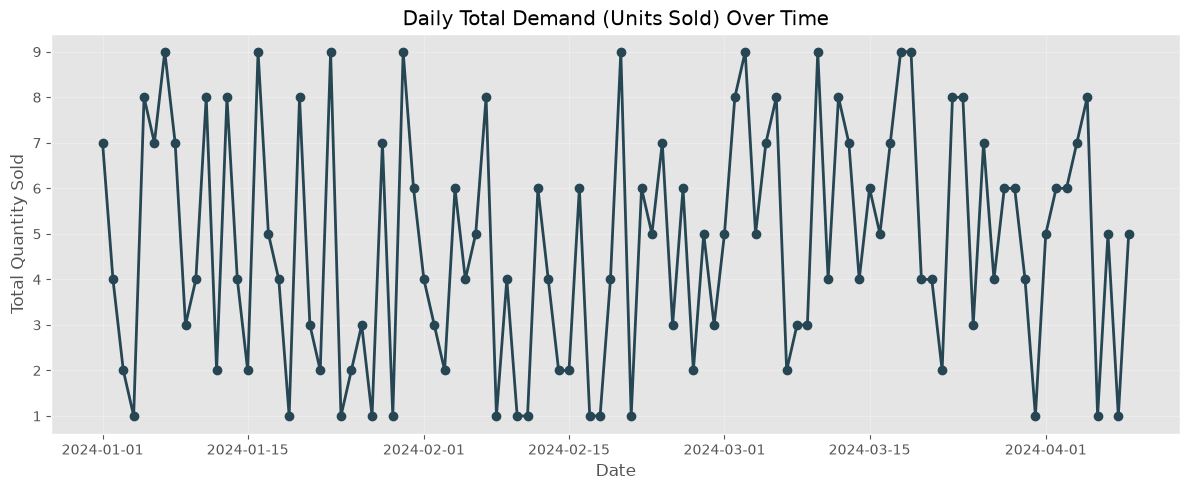

In [38]:
# Aggregate daily demand (Quantity) and Sales
daily_trends = df.groupby('Date').agg({'Quantity': 'sum', 'Total_Sales': 'sum'}).reset_index()
daily_trends = daily_trends.sort_values('Date')

plt.figure(figsize=(12, 5))
plt.plot(daily_trends['Date'], daily_trends['Quantity'], marker='o', linestyle='-', color='#264653', linewidth=2)
plt.title('Daily Total Demand (Units Sold) Over Time')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Create processed directory if it doesn't exist
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)

# Save cleaned dataframe
processed_path = os.path.join(processed_dir, 'cleaned_sales_data.csv')
df.to_csv(processed_path, index=False)

print(f"Cleaned dataset successfully saved to: {processed_path}")

Cleaned dataset successfully saved to: ../data/processed\cleaned_sales_data.csv


In [40]:
import pandas as pd

# Load the cleaned dataset
df_features = pd.read_csv('../data/processed/cleaned_sales_data.csv')
df_features['Date'] = pd.to_datetime(df_features['Date'])

# Extract useful time-based features
df_features['Month'] = df_features['Date'].dt.month
df_features['DayOfWeek'] = df_features['Date'].dt.dayofweek
# 1 if Saturday (5) or Sunday (6), else 0
df_features['IsWeekend'] = df_features['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0) 

print("Extracted Time Features:")
display(df_features[['Date', 'Month', 'DayOfWeek', 'IsWeekend']].head())

Extracted Time Features:


,Date,Month,DayOfWeek,IsWeekend
0,2024-01-01,1,0,0
1,2024-01-02,1,1,0
2,2024-01-03,1,2,0
3,2024-01-04,1,3,0
4,2024-01-05,1,4,0


In [41]:
# Drop 'Total_Sales' to prevent data leakage (since Total_Sales = Quantity * Price)
# Drop 'Customer_ID' because we are forecasting overall demand, not individual behavior
# Drop 'Date' since we've already extracted the necessary numerical features from it
columns_to_drop = ['Total_Sales', 'Customer_ID', 'Date']
df_features = df_features.drop(columns=columns_to_drop)

print("Remaining Predictors:")
print(df_features.columns.tolist())

Remaining Predictors:
['Product', 'Quantity', 'Price', 'Region', 'Month', 'DayOfWeek', 'IsWeekend']


In [42]:
# Convert categorical columns into numerical binary columns (0 or 1)
df_ml_ready = pd.get_dummies(df_features, columns=['Product', 'Region'], drop_first=False)

# Convert boolean columns to integers (if get_dummies outputs True/False)
df_ml_ready = df_ml_ready.astype(int)

print(f"New Dataset Shape: {df_ml_ready.shape}")
display(df_ml_ready.head())

New Dataset Shape: (100, 14)


,Quantity,Price,Month,DayOfWeek,IsWeekend,Product_Headphones,Product_Laptop,Product_Monitor,Product_Phone,Product_Tablet,Region_East,Region_North,Region_South,Region_West
0,7,37300,1,0,0,0,0,0,1,0,1,0,0,0
1,4,15406,1,1,0,1,0,0,0,0,0,1,0,0
2,2,21746,1,2,0,0,0,0,1,0,0,0,0,1
3,1,30895,1,3,0,1,0,0,0,0,1,0,0,0
4,8,39835,1,4,0,0,1,0,0,0,0,1,0,0


In [43]:
# Save the feature-engineered dataset
ml_data_path = '../data/processed/ml_ready_data.csv'
df_ml_ready.to_csv(ml_data_path, index=False)

print(f"ML-ready dataset successfully saved to: {ml_data_path}")

ML-ready dataset successfully saved to: ../data/processed/ml_ready_data.csv


In [44]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load the ML-ready dataset
df_ml = pd.read_csv('../data/processed/ml_ready_data.csv')

# Separate features (X) and target (y)
# We are predicting 'Quantity'
y = df_ml['Quantity']
X = df_ml.drop(columns=['Quantity'])

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (80, 13)
Testing data shape: (20, 13)


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize models
models = {
    "Baseline (Linear Regression)": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store results
results = []
trained_models = {}

print("Model Evaluation Results:\n" + "-"*40)

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Make predictions on the test set
    predictions = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })
    
    print(f"{name}:")
    print(f"  MAE (Avg units off): {mae:.2f}")
    print(f"  RMSE:                {rmse:.2f}")
    print(f"  R2 Score:            {r2:.4f}\n")

# Save results to a CSV for the final report
results_df = pd.DataFrame(results)
results_df.to_csv('../results/model_metrics.csv', index=False)

Model Evaluation Results:
----------------------------------------


Baseline (Linear Regression):
  MAE (Avg units off): 2.31
  RMSE:                2.72
  R2 Score:            -0.0512

Random Forest:
  MAE (Avg units off): 2.58
  RMSE:                3.04
  R2 Score:            -0.3179

Gradient Boosting:
  MAE (Avg units off): 2.48
  RMSE:                3.13
  R2 Score:            -0.3934



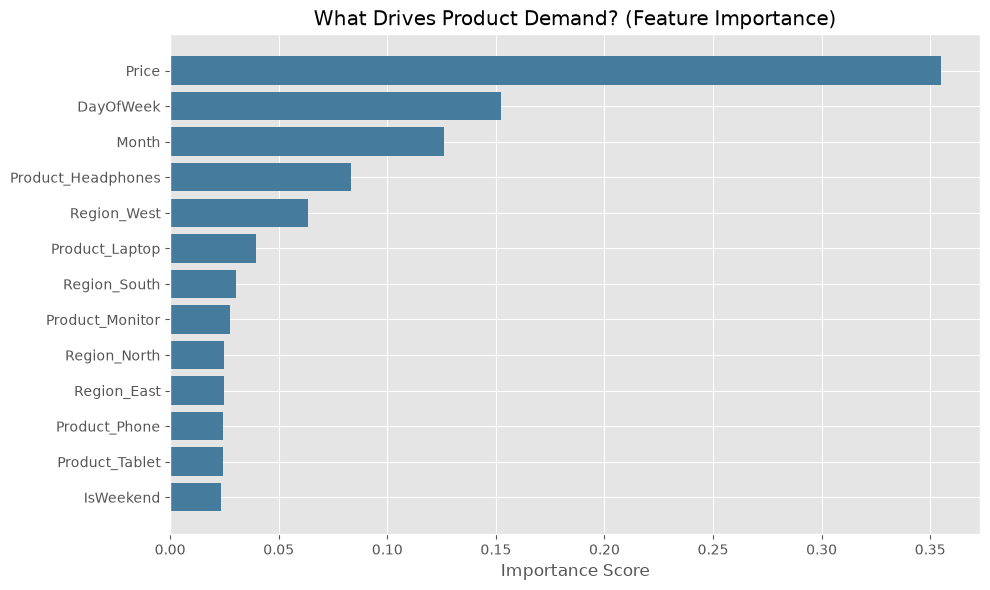

Model successfully saved to: ../models\demand_forecasting_model.joblib


['../models\\model_features.joblib']

In [46]:
import joblib
import os
import matplotlib.pyplot as plt

# Get feature importances from the Random Forest model
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='#457b9d')
plt.title('What Drives Product Demand? (Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Save the chosen model (We'll use Random Forest for the deployment phase)
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, 'demand_forecasting_model.joblib')

joblib.dump(rf_model, model_path)
print(f"Model successfully saved to: {model_path}")

# Also save the exact column names so our API knows what features to expect
joblib.dump(X.columns.tolist(), os.path.join(models_dir, 'model_features.joblib'))

In [47]:
import pandas as pd
import numpy as np

def generate_inventory_recommendation(predicted_demand, current_inventory):
    """
    Translates ML predicted demand into business inventory actions.
    """
    predicted_demand = max(0, int(predicted_demand)) # Demand cannot be negative
    
    # Business Rule: Maintain a 20% safety stock buffer above expected demand
    safety_stock = int(predicted_demand * 0.20)
    target_inventory = predicted_demand + safety_stock
    
    # Calculate how many units need to be ordered to reach target inventory
    reorder_qty = max(0, target_inventory - current_inventory)
    
    # Determine the business risk level
    if current_inventory < predicted_demand:
        risk_level = "HIGH STOCKOUT RISK"
    elif current_inventory < target_inventory:
        risk_level = "MODERATE RISK"
    elif current_inventory > (target_inventory * 1.5):
        risk_level = "OVERSTOCK RISK (Wasted Capital)"
    else:
        risk_level = "OPTIMAL INVENTORY"
        
    return {
        "Predicted_Demand": predicted_demand,
        "Current_Inventory": current_inventory,
        "Safety_Stock": safety_stock,
        "Target_Inventory": target_inventory,
        "Reorder_Quantity": reorder_qty,
        "Stock_Risk": risk_level
    }

# Test the function with a dummy scenario
# e.g., We predict selling 120 units, but only have 80 in stock
test_rec = generate_inventory_recommendation(predicted_demand=120, current_inventory=80)
print("TEST SCENARIO:")
for k, v in test_rec.items():
    print(f"{k}: {v}")

TEST SCENARIO:
Predicted_Demand: 120
Current_Inventory: 80
Safety_Stock: 24
Target_Inventory: 144
Reorder_Quantity: 64
Stock_Risk: HIGH STOCKOUT RISK


In [48]:
import random

# We will use the 'predictions' array and 'X_test' from Phase 4 (Cell 11)
recommendations = []

# Take a sample of 10 predictions
for i in range(10):
    pred = predictions[i]
    
    # Simulate current inventory (randomly ranging from 50% to 150% of the predicted demand)
    simulated_inventory = int(pred * random.uniform(0.5, 1.5))
    
    rec = generate_inventory_recommendation(pred, simulated_inventory)
    rec['Scenario_ID'] = f"Sample_{i+1}"
    recommendations.append(rec)

# Create a clean DataFrame for the business report
df_recs = pd.DataFrame(recommendations)
cols = ['Scenario_ID', 'Predicted_Demand', 'Current_Inventory', 'Safety_Stock', 'Reorder_Quantity', 'Stock_Risk']
df_recs = df_recs[cols]

display(df_recs)

,Scenario_ID,Predicted_Demand,Current_Inventory,Safety_Stock,Reorder_Quantity,Stock_Risk
0,Sample_1,8,6,1,3,HIGH STOCKOUT RISK
1,Sample_2,5,5,1,1,MODERATE RISK
2,Sample_3,4,6,0,0,OPTIMAL INVENTORY
3,Sample_4,4,3,0,1,HIGH STOCKOUT RISK
4,Sample_5,4,4,0,0,OPTIMAL INVENTORY
5,Sample_6,4,3,0,1,HIGH STOCKOUT RISK
6,Sample_7,4,7,0,0,OVERSTOCK RISK (Wasted Capital)
7,Sample_8,5,6,1,0,OPTIMAL INVENTORY
8,Sample_9,1,1,0,0,OPTIMAL INVENTORY
9,Sample_10,3,3,0,0,OPTIMAL INVENTORY


In [49]:
import os

results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

# Save the sample recommendations
recs_path = os.path.join(results_dir, 'inventory_recommendations.csv')
df_recs.to_csv(recs_path, index=False)

print(f"Business recommendations successfully saved to: {recs_path}")

Business recommendations successfully saved to: ../results\inventory_recommendations.csv
